In [5]:
import os
import asyncio
import asyncpg
import pandas as pd
from dotenv import load_dotenv
import json

# Load environment variables from .env file
load_dotenv('../.env.production')

# Get database URL from environment
database_url = os.getenv('DATABASE_URL')

In [7]:

async def fetch_data():
    # Connect to the database
    conn = await asyncpg.connect(database_url)
    
    # Fetch log table data
    records = await conn.fetch('SELECT * FROM log')
    
    # Convert to DataFrame
    if records:
        log_df = pd.DataFrame(records, columns=records[0].keys())
    else:
        log_df = pd.DataFrame()
    
    await conn.close()
    return log_df

# Run the async function
log_df = await fetch_data()

log_df = log_df[log_df.deleted_at.isna()]
log_df["data"] = log_df["data"].apply(lambda x: json.loads(x))

log_df.head()

,id,created_at,updated_at,deleted_at,text,data,version
6,01JM15636T586W3SPBTK9Z5YQ1,2025-02-14T02:39:12.090Z,2025-02-14T02:39:12.090Z,None,had a hot chocolate,"[{'item': 'hot chocolate', 'action': 'drank', ...",80
15,01JM2CTWX8TBXB1NHD4BV9R3KA,2025-02-14T14:12:01.000Z,2025-02-14T14:12:01.000Z,None,Tried to poop but couldn’t,"[{'effort': 'high', 'schema': 'pooped', 'poopT...",88
17,01JM2K7HFWZVCAPJFR75VCE0HS,2025-02-14T16:03:48.000Z,2025-02-14T16:03:48.000Z,None,Stomach feeling a bit unsettled,"[{'schema': 'symptom', 'startedAt': '2025-02-1...",90
21,01JM2M1P2M8BAD8EJ4XFM7NH2Y,2025-02-14T16:18:03.000Z,2025-02-14T16:18:03.000Z,None,Small poop. A little wet,"[{'effort': 'low', 'schema': 'pooped', 'poopTy...",91
22,01JM2VK0XF7Y22PK1M9DJBZPXQ,2025-02-14T18:29:54.000Z,2025-02-14T18:29:54.000Z,None,Vegetable and chickpea soup and 1 glass of water,"[{'item': 'vegetable and chickpea soup', 'acti...",92


In [10]:
log_df.head()

,id,created_at,updated_at,deleted_at,text,data,version
6,01JM15636T586W3SPBTK9Z5YQ1,2025-02-14T02:39:12.090Z,2025-02-14T02:39:12.090Z,None,had a hot chocolate,"[{'item': 'hot chocolate', 'action': 'drank', ...",80
15,01JM2CTWX8TBXB1NHD4BV9R3KA,2025-02-14T14:12:01.000Z,2025-02-14T14:12:01.000Z,None,Tried to poop but couldn’t,"[{'effort': 'high', 'schema': 'pooped', 'poopT...",88
17,01JM2K7HFWZVCAPJFR75VCE0HS,2025-02-14T16:03:48.000Z,2025-02-14T16:03:48.000Z,None,Stomach feeling a bit unsettled,"[{'schema': 'symptom', 'startedAt': '2025-02-1...",90
21,01JM2M1P2M8BAD8EJ4XFM7NH2Y,2025-02-14T16:18:03.000Z,2025-02-14T16:18:03.000Z,None,Small poop. A little wet,"[{'effort': 'low', 'schema': 'pooped', 'poopTy...",91
22,01JM2VK0XF7Y22PK1M9DJBZPXQ,2025-02-14T18:29:54.000Z,2025-02-14T18:29:54.000Z,None,Vegetable and chickpea soup and 1 glass of water,"[{'item': 'vegetable and chickpea soup', 'acti...",92


In [17]:
events_df = log_df.explode("data").dropna(subset=["data"])
events_df["source_text"] = events_df["text"]
events_df["started_at"] = events_df["data"].apply(lambda x: x.get("startedAt", None))
events_df = events_df[["started_at", "data", "source_text"]]
events_df.sort_values("started_at", ascending=True).tail(10)


,started_at,data,source_text
531,2025-03-29T19:00:00-04:00,"{'item': 'water', 'action': 'drank', 'amount':...",Ate a slice of pizza at 7pm last night and 500...
533,2025-03-30T09:13:58-04:00,"{'item': 'omega 3', 'action': 'took', 'amount'...","Ate nutty pudding, coffee, 500ml water, and om..."
533,2025-03-30T09:13:58-04:00,"{'item': 'water', 'action': 'drank', 'amount':...","Ate nutty pudding, coffee, 500ml water, and om..."
533,2025-03-30T09:13:58-04:00,"{'item': 'vitamin D', 'action': 'took', 'amoun...","Ate nutty pudding, coffee, 500ml water, and om..."
533,2025-03-30T09:13:58-04:00,"{'item': 'nutty pudding', 'action': 'ate', 'am...","Ate nutty pudding, coffee, 500ml water, and om..."
533,2025-03-30T09:13:58-04:00,"{'item': 'coffee', 'action': 'drank', 'amount'...","Ate nutty pudding, coffee, 500ml water, and om..."
534,2025-03-30T10:26:45-04:00,"{'size': 'small', 'effort': 'medium', 'schema'...",Small poop. Medium effort
535,2025-03-30T13:30:49-04:00,"{'item': 'meatloaf', 'action': 'ate', 'amount'...","Ate pork pasta, meatloaf, and 500ml water"
535,2025-03-30T13:30:49-04:00,"{'item': 'pork pasta', 'action': 'ate', 'amoun...","Ate pork pasta, meatloaf, and 500ml water"
535,2025-03-30T13:30:49-04:00,"{'item': 'water', 'action': 'drank', 'amount':...","Ate pork pasta, meatloaf, and 500ml water"


In [45]:
events_df.sort_values("started_at", ascending=True).to_csv("events.csv", index=False)

In [112]:
import pint
ureg = pint.UnitRegistry()

water_df = events_df[events_df["data"].apply(lambda x: "water" in x.get("item", "") or "tea" in x.get("item", ""))]
water_df = water_df.sort_values("started_at", ascending=True).reset_index(drop=True)
water_df["amount"] = water_df["data"].apply(lambda x: x.get("amount", ""))

water_df["normalized_amount"] = water_df["amount"] \
    .apply(lambda x: "1 cup" if x == "1" or x == "1 serving" else x) \
    .apply(lambda x: "500 millileters" if x == "1 glass" else x)

# Convert string measurements to pint quantities
def parse_measurement(measurement_str):
    try:
        # Handle empty/invalid values
        if not measurement_str or pd.isna(measurement_str):
            return None
        
        # Clean up the input string
        measurement_str = measurement_str.lower().replace('millileters', 'milliliters')
        
        # Parse the measurement
        return ureg.Quantity(measurement_str)
    except:
        return None

# Add new columns for the parsed quantity and everything in milliliters
water_df["quantity"] = water_df["normalized_amount"].apply(parse_measurement)
water_df["ml"] = water_df["quantity"].apply(lambda x: x.to('milliliters').magnitude if x else None)
water_df["date"] = pd.to_datetime(water_df["started_at"]).apply(lambda x: x.date())
water_df.head()

,started_at,data,source_text,amount,normalized_amount,quantity,ml,date
0,2025-02-14T10:30:53-05:00,"{'item': 'tea', 'action': 'drank', 'amount': '...",30min ago had 2 egg omelette and half apple an...,1,1 cup,1 cup,236.588236,2025-02-14
1,2025-02-14T13:29:54-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Vegetable and chickpea soup and 1 glass of water,1 glass,500 millileters,500 milliliter,500.000000,2025-02-14
2,2025-02-14T16:17:34-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Drank 1L water,1 liter,1 liter,1 liter,1000.000000,2025-02-14
3,2025-02-14T21:00:00-05:00,"{'item': 'water', 'action': 'drank', 'amount':...","Last night had: 2 pieces of pizza, a salad, ti...",1 glass,500 millileters,500 milliliter,500.000000,2025-02-14
4,2025-02-15T08:30:00-05:00,"{'item': 'decaf tea', 'action': 'drank', 'amou...","at 8:30am, at toast with peanut butter, a bana...",1 cup,1 cup,1 cup,236.588236,2025-02-15


In [115]:
poop_df = events_df[events_df["data"].apply(lambda x: x.get("schema", "") == "pooped")]
poop_df = pd.concat([
    poop_df[["started_at", "source_text"]].reset_index(drop=True),
    pd.DataFrame.from_records(poop_df["data"].values).drop(["startedAt", "schema"], axis=1).reset_index(drop=True)
], axis=1)
poop_df["effort_normalized"] = poop_df["effort"].apply(lambda x: 1 if x == "low" else 2 if x == "medium" else 3 if x == "high" else 2)
def parse_amount(row):
    if not pd.isna(row["size"]):
        return row["size"]
    if row["poopType"] == 0:
        return "none"
    source_text = row["source_text"].lower()
    if "couldn" in source_text or "none" in source_text:
        return "none"
    elif "small" in source_text or "little" in source_text:
        return "small"
    else:
        return "normal"
poop_df["size"] = poop_df.apply(lambda x: parse_amount(x), axis=1)
poop_df["size_normalized"] = poop_df["size"].apply(lambda x: 0 if x == "none" else 0.5 if x == "small" else 1 if x == "normal" else 1.5 if x == "large" else 1)
poop_df = poop_df.sort_values("started_at", ascending=True).reset_index(drop=True)
poop_df.head()

,started_at,source_text,effort,poopType,emptiness,empitness,size,duration,effort_normalized,size_normalized
0,2025-02-13T22:15:41-05:00,Tough poop. Long time. Small pieces,high,2,NaN,NaN,small,NaN,3,0.5
1,2025-02-14T09:12:01-05:00,Tried to poop but couldn’t,high,1,NaN,NaN,none,NaN,3,0.0
2,2025-02-14T11:18:03-05:00,Small poop. A little wet,low,6,NaN,NaN,small,NaN,1,0.5
3,2025-02-14T22:18:16-05:00,Difficult poop. No success,high,1,NaN,NaN,normal,NaN,3,1.0
4,2025-02-15T08:19:32-05:00,Long poop. Many pieces. Soft. Difficult,high,6,NaN,NaN,normal,NaN,3,1.0


In [118]:
# Convert started_at to date for both dataframes
poop_df['date'] = pd.to_datetime(poop_df['started_at']).apply(lambda x: x.date())

# Group by date and calculate metrics
daily_stats = poop_df.groupby('date').agg({
    # 'poopType': 'count',  # Count number of poops
    'effort_normalized': 'mean',  # Average effort
    'size_normalized': 'sum'  # Sum of normalized amounts
}).reset_index()

daily_stats["poop_count"] = poop_df[poop_df["poopType"] != 0].groupby('date')["poopType"].count().reset_index()["poopType"]

failed_attempts = poop_df[poop_df["poopType"] == 0].groupby('date')["poopType"].count().reset_index()
failed_attempts.rename(columns={"poopType": "failed_attempts"}, inplace=True)
daily_stats = daily_stats.merge(failed_attempts, on='date', how='left')

effort_max = poop_df.groupby('date')["effort_normalized"].max().reset_index()
effort_max.rename(columns={"effort_normalized": "effort_normalized_max"}, inplace=True)
daily_stats = daily_stats.merge(effort_max, on='date', how='left')

daily_stats.fillna(0, inplace=True)
daily_stats.head()

,date,effort_normalized,size_normalized,poop_count,failed_attempts,effort_normalized_max
0,2025-02-13,3.000000,0.5,1.0,0.0,3
1,2025-02-14,2.333333,1.5,3.0,0.0,3
2,2025-02-15,2.250000,2.5,3.0,1.0,3
3,2025-02-16,2.666667,0.5,1.0,2.0,3
4,2025-02-17,2.500000,1.5,2.0,0.0,3


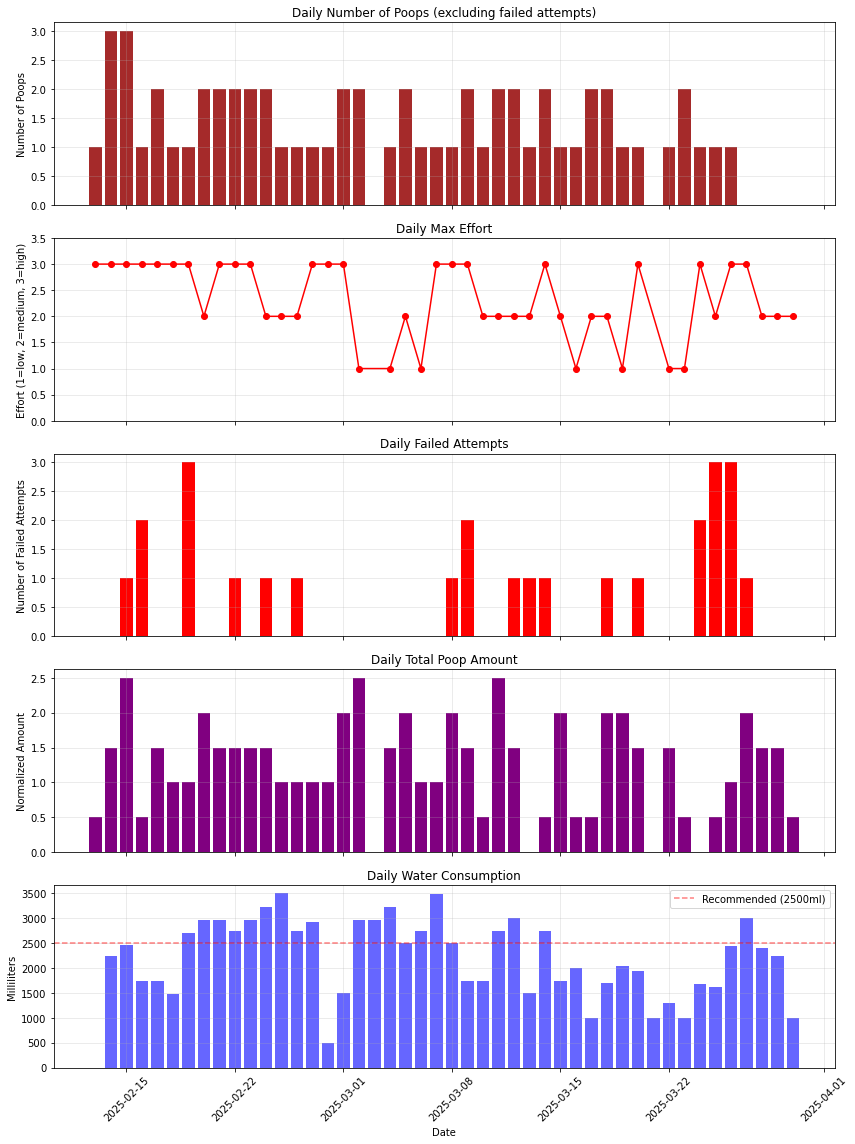

In [ ]:


# Get daily water consumption
daily_water_stats = water_df.groupby('date')['ml'].sum().reset_index()

# Create figure with four subplots sharing x-axis
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

# Plot number of poops
ax1.bar(daily_stats['date'], daily_stats['poop_count'], color='brown')
ax1.set_title('Daily Number of Poops (excluding failed attempts)')
ax1.set_ylabel('Number of Poops')
ax1.grid(True, alpha=0.3)

# Plot max effort
ax2.plot(daily_stats['date'], daily_stats['effort_normalized_max'], color='red', marker='o')
ax2.set_title('Daily Max Effort')
ax2.set_ylabel('Effort (1=low, 2=medium, 3=high)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 3.5)

# Plot failed attempts
ax3.bar(daily_stats['date'], daily_stats['failed_attempts'], color='red')
ax3.set_title('Daily Failed Attempts')
ax3.set_ylabel('Number of Failed Attempts')
ax3.grid(True, alpha=0.3)

# Plot total normalized amount
ax4.bar(daily_stats['date'], daily_stats['size_normalized'], color='purple')
ax4.set_title('Daily Total Poop Amount')
ax4.set_ylabel('Normalized Amount')
ax4.grid(True, alpha=0.3)

# Plot water consumption
ax5.bar(daily_water_stats['date'], daily_water_stats['ml'], color='blue', alpha=0.6)
ax5.set_title('Daily Water Consumption')
ax5.set_ylabel('Milliliters')
ax5.set_xlabel('Date')
ax5.grid(True, alpha=0.3)
ax5.axhline(y=2500, color='r', linestyle='--', alpha=0.5, label='Recommended (2500ml)')
ax5.legend()

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
